# Optimized Spam Detection System


This notebook builds and compares multiple machine learning models to classify SMS/email messages as **Spam** or **Ham**, then selects and saves the best-performing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## 1. Load Dataset

In [2]:
import os

candidate_paths = ["../data/spam.csv", "./data/spam.csv", "data/spam.csv", "spam.csv"]
data_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(data_path, encoding='latin-1')
print(f"Loaded dataset from: {data_path}")

Loaded dataset from: ../data/spam.csv


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
df["v1"].value_counts()




v1
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
df["v2"].value_counts()


v2
Sorry, I'll call later                                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                                    12
Ok...                                                                                                                                                                                  10
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed å£1000 cash or å£5000 prize!                                   4
Wen ur lovable bcums angry wid u, dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda manda... Have nice day da.     4
                                                                   

In [10]:
print(df["v1"].value_counts(normalize=True) * 100)


v1
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


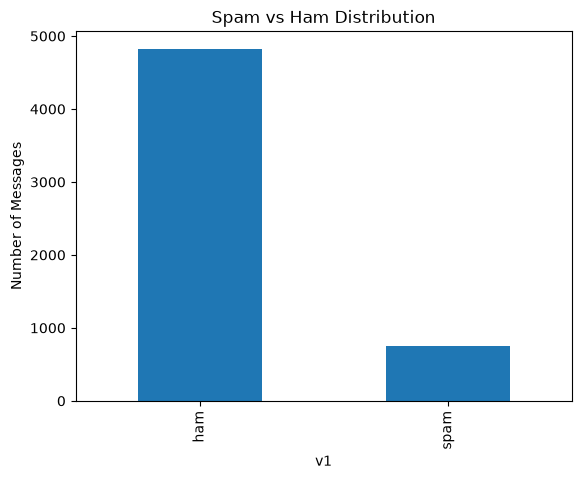


Spam Examples:
      v1                                                 v2 Unnamed: 2  \
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
5   spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
8   spam  WINNER!! As a valued network customer you have...        NaN   
9   spam  Had your mobile 11 months or more? U R entitle...        NaN   
11  spam  SIX chances to win CASH! From 100 to 20,000 po...        NaN   
12  spam  URGENT! You have won a 1 week FREE membership ...        NaN   
15  spam  XXXMobileMovieClub: To use your credit, click ...        NaN   
19  spam  England v Macedonia - dont miss the goals/team...        NaN   
34  spam  Thanks for your subscription to Ringtone UK yo...        NaN   
42  spam  07732584351 - Rodger Burns - MSG = We tried to...        NaN   

   Unnamed: 3 Unnamed: 4  
2         NaN        NaN  
5         NaN        NaN  
8         NaN        NaN  
9         NaN        NaN  
11        NaN        NaN  
12     

In [11]:
df["v1"].value_counts().plot(kind="bar")

plt.xlabel("v1")
plt.ylabel("Number of Messages")
plt.title("Spam vs Ham Distribution")
plt.show()

# Spam Examples
print("\nSpam Examples:")
print(df[df["v1"] == "spam"].head(10))

# Ham Examples
print("\nHam Examples:")
print(df[df["v1"] == "ham"].head(10))

## 3. Data Cleaning

In [12]:
# data not cleaned yet, so we will drop the unnecessary columns and rename the remaining columns to make them more meaningful.

df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
print(df.head())
print(df.shape)
print(df.columns)

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
Index(['v1', 'v2'], dtype='str')


In [13]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [14]:
df.rename(columns={"v1": "Label", "v2": "Message"}, inplace=True)

In [15]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(403)

In [17]:
df=df.drop_duplicates()

In [18]:
df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
print(df["Label"].unique())

<ArrowStringArray>
['ham', 'spam']
Length: 2, dtype: str


In [21]:
df["Label"] = df["Label"].map({"ham": 0, "spam": 1})

In [22]:
df

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [23]:
df["Label"].value_counts()

Label
0    4516
1     653
Name: count, dtype: int64

In [24]:
df["Message"].head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: str

## 4. Text Preprocessing

In [25]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

# Apply cleaning
df["clean_message"] = df["Message"].apply(clean_text)


print(df["clean_message"].iloc[0])


go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [26]:
df

,Label,Message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,this is the nd time we have tried contact u u ...
5568,0,Will Ì_ b going to esplanade fr home?,will b going to esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggestions
5570,0,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...


In [27]:
print(df.columns)
print(df.shape)
print(df.isnull().sum())
print(df["Label"].value_counts())

Index(['Label', 'Message', 'clean_message'], dtype='str')
(5169, 3)
Label            0
Message          0
clean_message    0
dtype: int64
Label
0    4516
1     653
Name: count, dtype: int64


## 5. Feature Extraction (TF-IDF)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

X = tfidf.fit_transform(df["clean_message"])

y = df["Label"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

features = tfidf.get_feature_names_out()

print("\nNumber of features:", len(features))
print("\nFirst 50 features:")
print(features[:50])

print("\nFirst message TF-IDF:")
print(X[0])

X shape: (5169, 8183)
y shape: (5169,)

Number of features: 8183

First 50 features:
['aa' 'aah' 'aaniye' 'aaooooright' 'aathilove' 'aathiwhere' 'ab' 'abbey'
 'abdomen' 'abeg' 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj' 'able'
 'abnormally' 'aboutas' 'abroad' 'absence' 'absolutely' 'abstract' 'abt'
 'abta' 'aburo' 'abuse' 'abusers' 'ac' 'academic' 'acc' 'accent'
 'accenture' 'accept' 'access' 'accessible' 'accidant' 'accident'
 'accidentally' 'accommodation' 'accommodationvouchers' 'accomodate'
 'accomodations' 'accordin' 'accordingly' 'accordinglyor' 'account'
 'accounting' 'accounts' 'accumulation']

First message TF-IDF:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (1, 8183)>
  Coords	Values
  (0, 3598)	0.3495420025747496
  (0, 5297)	0.27275071770580317
  (0, 1500)	0.2700280579515215
  (0, 457)	0.2700280579515215
  (0, 896)	0.2948347874195931
  (0, 2840)	0.1963641842209221
  (0, 7978)	0.25148034514968953
  (0, 3750)	0.28602889264384

In [29]:
df.head()

,Label,Message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 6. Train / Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [31]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4135, 8183)
X_test: (1034, 8183)
y_train: (4135,)
y_test: (1034,)


## 7. Model Training & Evaluation

### 7.1 Naive Bayes

In [32]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8183)","[[0.34,1.39,0.1 ,...,0. ,0. ,0.17], [0. ,0. ,0. ,...,0.33,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8183)","[[-9.43,-8.85,-9.63,...,-9.72,-9.72,-9.57], [-9.2 ,-9.2 ,-9.2 ,...,-8.91,-9.2 ,-9.2 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8183


In [33]:
y_pred_nb = nb_model.predict(X_test)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")

Naive Bayes Accuracy: 0.965183752417795
Naive Bayes Accuracy: 96.52%


### 7.2 Logistic Regression

In [34]:


# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

Logistic Regression Accuracy: 0.9439071566731141
Logistic Regression Accuracy: 94.39%


### 7.3 Support Vector Machine (SVM)

In [35]:
# Create model
svm_model = SVC(probability=True, random_state=42)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")

c:\Users\Kareem Ahmed\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Accuracy: 0.9661508704061895
SVM Accuracy: 96.62%


### 7.4 Classification Reports — All Models

In [36]:
from sklearn.metrics import classification_report

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("SVM")
print(classification_report(y_test, y_pred_svm))

Naive Bayes
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       0.99      0.56      0.72       131

    accuracy                           0.94      1034
   macro avg       0.96      0.78      0.84      1034
weighted avg       0.95      0.94      0.94      1034

SVM
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       1.00      0.73      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97     

### 7.5 Confusion Matrix — SVM

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

[[903   0]
 [ 35  96]]


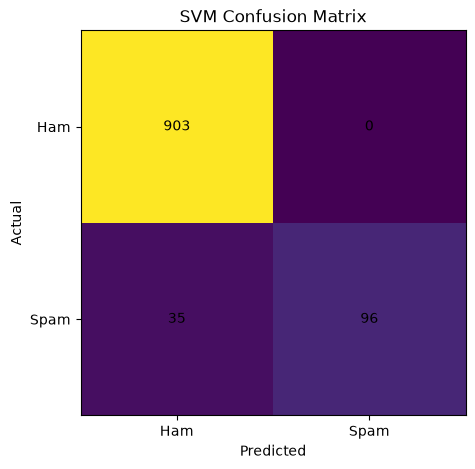

In [38]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],ha="center",va="center")

plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.73      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



### 7.6 Hyperparameter Tuning (GridSearchCV) — Optimized SVM

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_svm = grid_search.best_estimator_

y_pred_best_svm = best_svm.predict(X_test)

accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)

print(f"Optimized SVM Accuracy: {accuracy_best_svm * 100:.2f}%")

c:\Users\Kareem Ahmed\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score:
0.8947511624817324
Optimized SVM Accuracy: 97.97%


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

print("Optimized SVM Classification Report")
print(
    classification_report(
        y_test,
        y_pred_best_svm,
        target_names=["Ham", "Spam"]
    )
)

print("\nConfusion Matrix:")
cm_best = confusion_matrix(y_test, y_pred_best_svm)
print(cm_best)

Optimized SVM Classification Report
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.99      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix:
[[902   1]
 [ 20 111]]


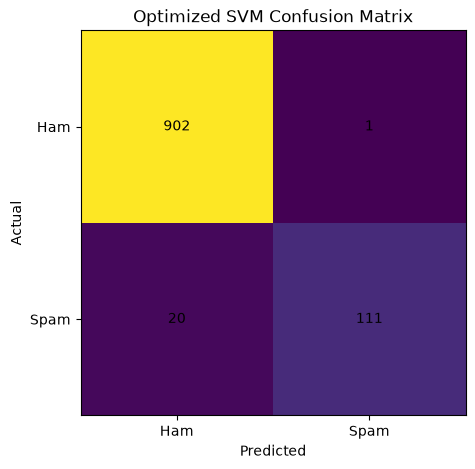

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm_best)

plt.title("Optimized SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_best[i, j],
            ha="center",
            va="center"
        )

plt.show()

### 7.7 Random Forest

In [43]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

In [44]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [45]:
y_pred_rf = rf_model.predict(X_test)

In [46]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 0.9700193423597679
Random Forest Accuracy: 97.00%


In [47]:
print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Ham", "Spam"]
    )
)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Classification Report
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.77      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.93      1034
weighted avg       0.97      0.97      0.97      1034


Confusion Matrix:
[[902   1]
 [ 30 101]]


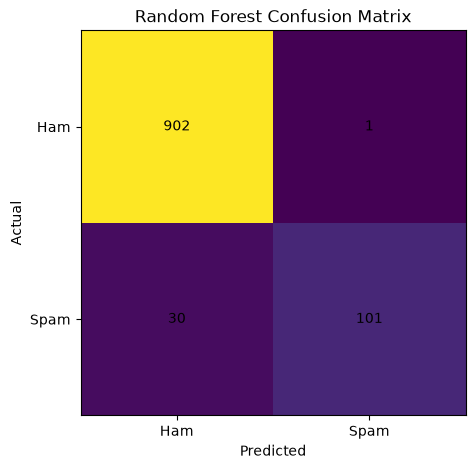

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm_rf)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.show()

## 8. Final Model Comparison

In [49]:

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Optimized SVM"
    ],

    "Accuracy": [
        accuracy_nb * 100,
        accuracy_lr * 100,
        accuracy_rf * 100,
        accuracy_svm * 100,
        accuracy_best_svm * 100
    ]
})

print(model_comparison)

                 Model   Accuracy
0          Naive Bayes  96.518375
1  Logistic Regression  94.390716
2        Random Forest  97.001934
3                  SVM  96.615087
4        Optimized SVM  97.969052


In [50]:
# Sort models by accuracy

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("Final Model Ranking:")
print(model_comparison)

Final Model Ranking:
                 Model   Accuracy
4        Optimized SVM  97.969052
2        Random Forest  97.001934
3                  SVM  96.615087
0          Naive Bayes  96.518375
1  Logistic Regression  94.390716


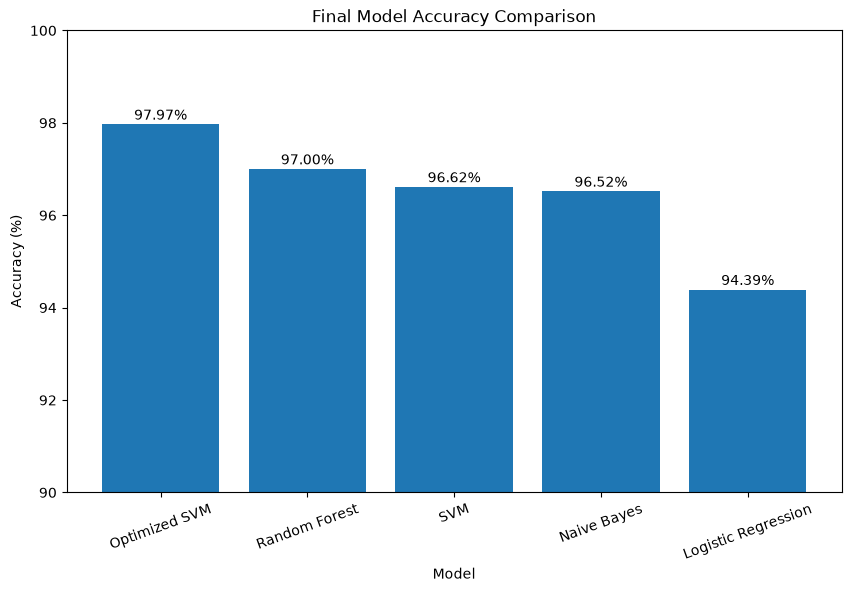

In [57]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(90, 100)

plt.xticks(rotation=20)

# Display accuracy values
for bar, accuracy in zip(
    bars,
    model_comparison["Accuracy"]
):
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

## 9. Best Model Summary

In [56]:
best_model = model_comparison.iloc[0]

print("Best Model:")
print(best_model["Model"])

print(
    f"Best Accuracy: {best_model['Accuracy']:.2f}%"
)

Best Model:
Optimized SVM
Best Accuracy: 97.97%


## 10. Save Best Model & Vectorizer

Persist the optimized SVM model and the fitted TF-IDF vectorizer so they can be reloaded later (e.g. by the Streamlit app) without retraining.

In [55]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_svm, "../models/spam_classifier_svm.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Saved best model to ../models/spam_classifier_svm.pkl")
print("Saved TF-IDF vectorizer to ../models/tfidf_vectorizer.pkl")

Saved best model to ../models/spam_classifier_svm.pkl
Saved TF-IDF vectorizer to ../models/tfidf_vectorizer.pkl
